# Cost-benefit calculations — extended with 3 additional measures

This notebook extends `09_costbenefit.ipynb` for the Workshop 3 intersessional exercise. It uses the v2 Entity file, which adds three measures to the original three (River dredging, Rebuilding levees, Early warning system):

- **School floor raising** — raises school floors by 40 cm (hazard linear transform, `a=1, b=-0.4`)
- **Portfolio flood insurance for schools** — portfolio-level risk transfer (attachment/cover derived from the model's own exceedance curve)
- **Partial relocation of high-risk schools** — the 5 schools with the highest RP100 flood depth have 60% of their value relocated out of the flood zone (Exposures swap via HDF5)

All other data and calculation steps are identical to notebook 09.

## Read in Data

In [1]:
from pathlib import Path

# -----------------------------------------------------
# Set up paths to data
# -----------------------------------------------------

ENTITY_DIR = "../data/entity_files_adaptation/"
ENTITY_FILE = "Porto_Alegre_BRAZIL_Entity_Floods_Schools_calibrated_measures_v2.xlsx"
entity_path = Path(ENTITY_DIR) / ENTITY_FILE

# Here we use the JRC return period flood data
HAZARD_DIR = "../data/hazard/"
HAZARD_RETURN_PERIODS = [10, 20, 50, 100, 200, 500]
HAZARD_FILES = [f"PortoAlegre_RP{rp}_depth.tif" for rp in HAZARD_RETURN_PERIODS]
haz_paths = [Path(HAZARD_DIR) / f for f in HAZARD_FILES]

# -----------------------------------------------------
# Set constants
# -----------------------------------------------------

YEAR_PRESENT = 2025
YEAR_FUTURE = 2050

# Path to file with information on changes to return period frequencies
# Columns: scenario, year, return_period_present, return_period_future
FUTURE_HAZARD_FREQUENCIES_PATH = "../data/hazard/porto_alegre_rp_mapping_2025_2050.csv"


### Create present-day and future Entity objects

As in previous examples we don't read in a future Entity file. Instead create it from the present-day Entity by applying an annual growth rate to the assets and changing the reference year, keeping everything else the same.

In [2]:
import copy
from climada.entity import Entity, MeasureSet

# -----------------------------------------------------
# Create present and future Entity objects
# -----------------------------------------------------

entity_present = Entity.from_excel(entity_path)
entity_future = copy.deepcopy(entity_present)

entity_present.exposures.ref_year = YEAR_PRESENT
entity_present.exposures.value_unit = "USD"
entity_present.exposures.description = f"{YEAR_PRESENT} schools economic exposure"

entity_future.exposures.ref_year = YEAR_FUTURE
entity_future.exposures.value_unit = "USD"
entity_future.exposures.description = f"{YEAR_FUTURE} schools economic exposure"

# -----------------------------------------------------
# Scale future exposures for projected economic growth
# -----------------------------------------------------

# Set this figure to something realistic!
# Average annual projected growth rate of the economy during the study period
# (not inflation rate: all currency is in 2025 USD) 
ECONOMIC_GROWTH_RATE = 0.02

n_years = YEAR_FUTURE - YEAR_PRESENT
growth = (1 + ECONOMIC_GROWTH_RATE) ** n_years

new_gdf = entity_future.exposures.gdf
new_gdf["value"] = new_gdf["value"] * growth
entity_future.exposures.set_gdf(new_gdf)

print(f"Total value of exposures in {YEAR_PRESENT}: {entity_present.exposures.value.sum():,.2f} USD")
print(f"Total value of exposures in {YEAR_FUTURE}: {entity_future.exposures.value.sum():,.2f} USD")
print(f"Total proportional growth of exposures from {YEAR_PRESENT} to {YEAR_FUTURE}: {growth:,.2f}")

Total value of exposures in 2025: 305,000,000.00 USD
Total value of exposures in 2050: 500,384,828.31 USD
Total proportional growth of exposures from 2025 to 2050: 1.64


### Create present-day and future hazard objects

As in previous examples, we create future hazard information by adjusting the frequencies of present-day hazard footprints so that they occur more frequently. 

In [3]:
# -----------------------------------------------------
# Read hazard data
# -----------------------------------------------------

import numpy as np
import pandas as pd
from climada.hazard import Hazard

# Read the hazard data

# Since we're reading hazard data from .tif files, we need to provide some additional metadata, including a frequency for each event
# As shown in the Hazard notebook, we have to convert return period frequencies to event frequencies:
def event_frequency_from_return_periods(return_periods):
    rp_rev = copy.deepcopy(return_periods)[::-1]  # Reverse the list so that it's in order of increasing frequency (decreasing return period)
    exceedance_frequency = np.array([1/rp for rp in rp_rev])
    event_frequency = np.diff(np.concatenate([[0], exceedance_frequency]))
    event_frequency = event_frequency[::-1]  # Reverse the frequencies so that they match the order of the events in the hazard file again
    return event_frequency

event_frequency_present = event_frequency_from_return_periods(HAZARD_RETURN_PERIODS)

# Read in the hazard data
haz_present = Hazard.from_raster(
    files_intensity = haz_paths,
    attrs={
        'unit': 'm',
        'event_name': [f'Return period {rp}' for rp in HAZARD_RETURN_PERIODS],     # We can optionally name the events
        'frequency': event_frequency_present                                         # For probabilistic analyses we have to define the frequency of each event
    },
    haz_type='FL'
)


# -----------------------------------------------------
# Adjust event frequencies to create future hazard
# -----------------------------------------------------

future_rps_df = pd.read_csv(Path(FUTURE_HAZARD_FREQUENCIES_PATH))
assert future_rps_df["historical_return_period"].tolist() == HAZARD_RETURN_PERIODS, "The return periods in the future frequencies file do not match the return periods of the hazard data"

future_rps = future_rps_df["future_return_period_2050"]
event_frequency_future = event_frequency_from_return_periods(future_rps)

haz_future = copy.deepcopy(haz_present)
haz_future.event_name = [f'Return period {rp}' for rp in future_rps]
haz_future.frequency = event_frequency_future


In [4]:
# -----------------------------------------------------
# Assign hazard centroids to exposure points
# -----------------------------------------------------

entity_present.exposures.assign_centroids(haz_present)
entity_future.exposures.assign_centroids(haz_future)

### Future variant of the relocation measure

The 'Partial relocation of high-risk schools' measure swaps the Exposures for a pre-built HDF5 file. The present-day file holds 2025 values, but the future Entity's exposures include economic growth — if the future Entity's measure pointed at the 2025 file, the measure would appear to 'remove' the growth too and its benefit would be overstated. So we build a future variant (grown values, same 5 schools at 40%) and point the future Entity's measure at it.

This is done *after* `assign_centroids` so the saved file already carries the hazard-centroid matching.

In [5]:
from climada.entity import Exposures

RELOCATION_RETAINED_FRACTION = 0.4
MEASURE_RELOCATION = "Partial relocation of high-risk schools"

relocated_present = Exposures.from_hdf5(
    Path(ENTITY_DIR) / "Porto_Alegre_BRAZIL_Exposures_Schools_relocated.hdf5"
)

# Identify the relocated schools by comparing values with the unmodified present entity
relocated_mask = (
    relocated_present.gdf["value"].values
    < entity_present.exposures.gdf["value"].values
)
assert relocated_mask.sum() == 5, f"Expected 5 relocated schools, found {relocated_mask.sum()}"

future_gdf = entity_future.exposures.gdf.copy()
future_gdf.loc[relocated_mask, "value"] = (
    future_gdf.loc[relocated_mask, "value"] * RELOCATION_RETAINED_FRACTION
)
relocated_future = entity_future.exposures.copy(deep=True)
relocated_future.set_gdf(future_gdf)
relocated_future.ref_year = YEAR_FUTURE

relocated_future_path = Path(ENTITY_DIR) / "Porto_Alegre_BRAZIL_Exposures_Schools_relocated_2050.hdf5"
relocated_future.write_hdf5(relocated_future_path)

entity_future.measures.get_measure("FL", MEASURE_RELOCATION).exposures_set = str(
    relocated_future_path
)

print(f"Future relocated exposures written to {relocated_future_path}")
print(f"Unadapted future total value: {entity_future.exposures.gdf['value'].sum():,.2f} USD")
print(f"Adapted (relocated) future total value: {future_gdf['value'].sum():,.2f} USD")

Future relocated exposures written to ../data/entity_files_adaptation/Porto_Alegre_BRAZIL_Exposures_Schools_relocated_2050.hdf5
Unadapted future total value: 500,384,828.31 USD
Adapted (relocated) future total value: 488,080,283.35 USD


## Cost-Benefit calculation

We initialize a `CostBenefit` object and run the calculation with its `calc` method. This takes four key inputs: the present-day hazard, the present-day Entity, the future hazard and the future Entity.

To calculate the cost-benefit for a single Measure, CLIMADA performs four risk calculations:

- Present-day unadapted risk
- Present-day adapted risk
- Future unadapted risk
- Future adapted risk

The _benefit_ of a Measure is the sum of the impacts it prevents over the study time period. Each measure is assumed to be implemented in the first year of the analysis period (Note: this will be customizable in CLIMADA Version 7). The model calculates the benefits the Measure provides in the present-day and future climates (by subtracting the adapted risk from the unadapted risk). These benefits are interpolated from the start year to the end year, adjusted to their 'net present value' using the Discount Rates, and then summed to give a total benefit over the study period (see the `imp_time_depen` parameter for some control over how this interpolation is performed).

When it finishes the cost-benefit calculation prints statistics for each Measure and for all measures combined.

**Notes: negative values**

- Negative costs are allowed (when the Measure generates an income that exceeds its implementation costs over the studied time period), and will give a negative cost-benefit. You'll have to be careful while interpreting this.
- Negative benefits are allowed (when the Measure makes things worse), and will also give negative cost-benefits. If you see this and didn't expect to, check how you specified the Measure, negative benefits shouldn't show up unless you specify that the Measure makes things worse. 

**Notes: which data are read from which Entity file**

- If the future hazard or future entity is not specified, it is assumed not to change over time, and the present-day hazard or Entity is substituted
- Measures and Impact Functions should be kept the same in both the present and future Entities.
    - Be careful: the analysis won't necessary fail if this is not the case: CLIMADA allows changes to the Impact Functions (this become part of the 'Economic Development' component of the change in risk),  Changes to the Measures will throw an error when the measures have different names, and will otherwise become part of the avoided risk/benefits component of the analysis.
- Discount rates are read from the present-day Entity


In [6]:
from climada.engine import CostBenefit
from climada.engine.cost_benefit import risk_aai_agg

costben = CostBenefit()
costben.calc(
    haz_present,
    entity_present,
    haz_future=haz_future,
    ent_future=entity_future,
    assign_centroids=False
)


Measure                                    Cost (USD m)    Benefit (USD m)    Benefit/Cost
---------------------------------------  --------------  -----------------  --------------
River dredging                                  789.562           195.782         0.247963
Rebuilding levees                               161.171           257.866         1.59995
Early warning system                              1.5              32.0348       21.3566
School floor raising                              7.625            64.2438        8.42542
Portfolio flood insurance for schools           258.463           171.475         0.663442
Partial relocation of high-risk schools          10.5              34.7643        3.31089

--------------------  ---------  -------
Total climate risk:    320.348   (USD m)
Average annual risk:    19.0853  (USD m)
Residual risk:        -435.817   (USD m)
--------------------  ---------  -------
Net Present Values


In [7]:
names = entity_present.measures.get_names()["FL"]
assert len(names) == 6, f"Expected 6 measures, got {len(names)}: {names}"
assert all(name in costben.cost_ben_ratio for name in names), \
    "Missing cost_ben_ratio entry for some measure"
assert all(v == v for v in costben.benefit.values()), "Found NaN in benefits"  # v != v means NaN
print("6 measures present, no NaN benefits:", sorted(names))

6 measures present, no NaN benefits: ['Early warning system', 'Partial relocation of high-risk schools', 'Portfolio flood insurance for schools', 'Rebuilding levees', 'River dredging', 'School floor raising']


From this statistical summary we can already learn a few things:

- The levees measure has the highest benefit, but the early warning system has the highest benefit to cost ratio
- Dredging has a benefit to cost ratio less than one. This means that _based on losses to schools alone_ the measures prevent less damage than they cost to implement. This is to be expected: losses from schools made up only a small portion of the total flood impacts. A complete study would include benefits from other modelled asset types as well, including homes and businesses.
- The sum of the losses prevented by the measures (the total benefits) exceed the total risk over the study period, resulting in a negative residual risk. This is because some impacts are 'prevented' twice: e.g. the levees prevent losses that are also prevented by the early warning system.

## Visualizations

### Cost-benefit graph

The cost-benefit graph is a bar chart displaying the above statistics. Each bar represents a modelled adaptation measure:

- The bar width shows the Measure's benefit (the net present value of losses prevented over the study period). Wider bars have larger benefits.
- The bar height shows the Measure's benefit to cost ratio. Taller bars are better value for money. Bars with a benefit to cost ratio greater than 1 are considered to have a positive return on investment.

Two red points are marked on the x-axis to help understand the scale of benefits. The 'AAI' shows the average modelled loss in one year over the analysis period. The 'Tot risk' shows the total accumulated losses over the analysis period. If the bars extend beyond this second point, it means that the summed benefits of the Measures prevent more than the total unadapted loss, as discussed above.


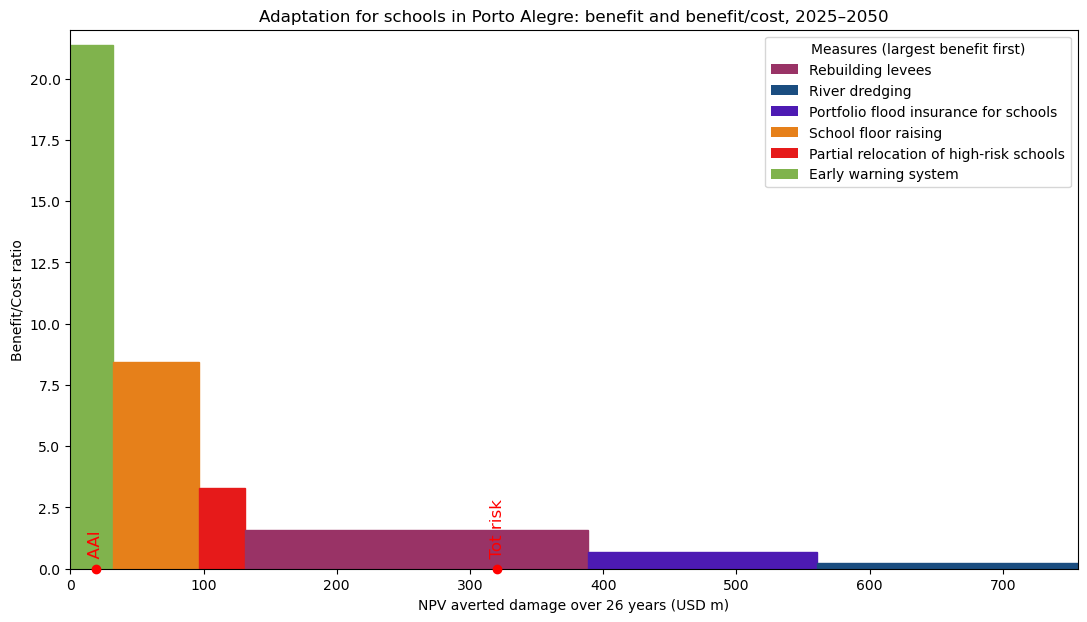

In [8]:
from pathlib import Path
from matplotlib.patches import Patch

OUTPUT_DIR = Path("../outputs/")
OUTPUT_DIR.mkdir(exist_ok=True)

ax = costben.plot_cost_benefit()
fig = ax.figure
fig.set_size_inches(13, 7)

# The default plot writes each measure's name vertically inside its bar, which
# overlaps badly with 6 measures — replace those in-bar labels with a legend, but
# keep the 'AAI'/'Tot risk' reference labels. CLIMADA pads these labels with
# leading spaces, so compare on the stripped text.
names = entity_present.measures.get_names()["FL"]
for text in list(ax.texts):
    if text.get_text().strip() in names:
        text.remove()

names_sorted = sorted(names, key=lambda n: costben.benefit[n], reverse=True)
handles = [
    Patch(
        facecolor=tuple(np.asarray(entity_present.measures.get_measure("FL", n).color_rgb)[:3]),
        label=n,
    )
    for n in names_sorted
]
ax.legend(handles=handles, loc="upper right", title="Measures (largest benefit first)")
ax.set_title("Adaptation for schools in Porto Alegre: benefit and benefit/cost, 2025\u20132050")
fig.savefig(OUTPUT_DIR / "brazil_schools_cost_benefit.png", dpi=420, bbox_inches="tight")

In this plot we see:

- The early warning systems are the tallest bar, showing the clearest positive return on investment. They have a benefit to cost ratio greater than one (even when evaluated against the single asset type of schools). Since there are many benefits to early warning systems that are not quantified in this analysis (e.g. preventing loss of life, emotional impacts of loss, long-term economic consequences), it seems that this is already a good idea – assuming that the prevented losses are accurate in the Measure.  
- The levees have the widest bar and therefore prevent the most losses. The benefit to cost ratio is also greater than one. Since this is a huge investment, we would need to look at the losses to homes and businesses that are prevented before we can quantify the total benefits. (Note: and make sure the upkeep costs are included.)


## Benefits by return period

It can be useful to understand _what kind of event_ your Measures protect against. Some measures may only pretect against less intense events; some may be most beneficial at long return periods.

To do this we can use the `CostBenefit.plot_event_view` method, which shows the losses prevented at different modelled return periods. During the CostBenefit calculation, CLIMADA saved exceedance frequency curves for adapted and unadapted climates, meaning the benefits of measures can be estimated for different severities of event.

The plot has a bar for each requested return period. A black outline shows the unadapted risk, and filled bars are overlaid showing how much risk each measure offsets. Again, when the total stacked amount is larger than the black outline, the total benefit is larger than the modelled impacts.

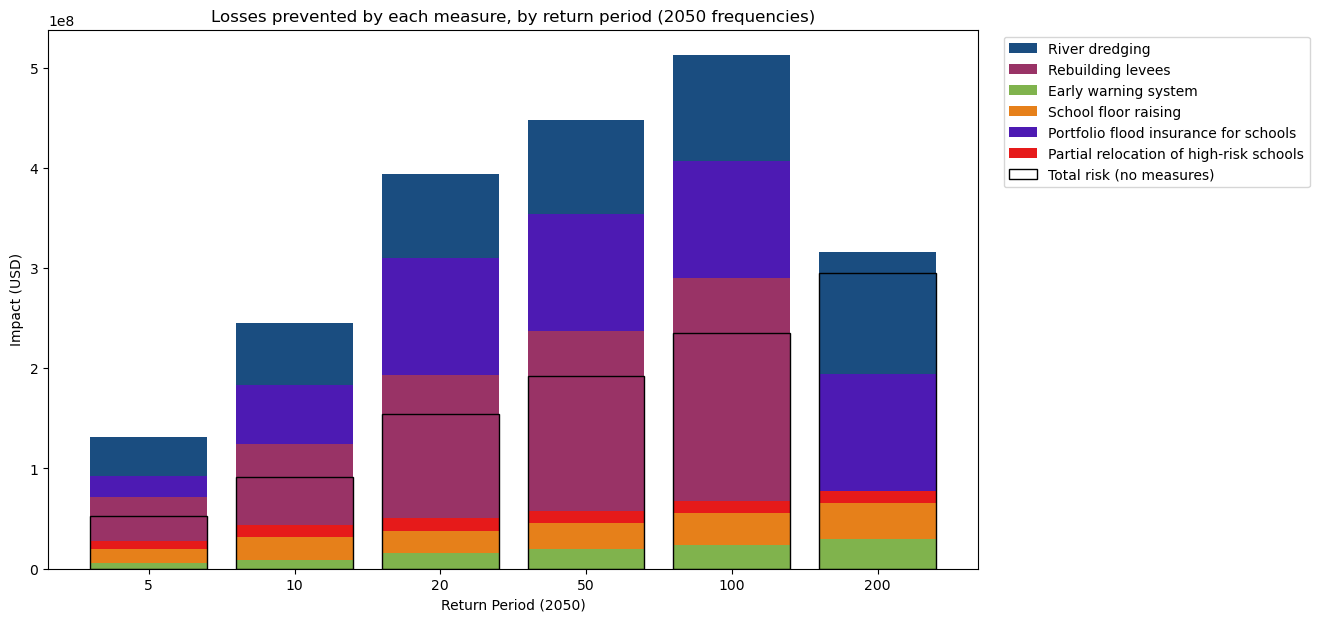

In [9]:
from matplotlib.patches import Patch

ax = costben.plot_event_view(return_per=future_rps)
fig = ax.figure
fig.set_size_inches(12, 7)

names = entity_present.measures.get_names()["FL"]
handles = [
    Patch(
        facecolor=tuple(np.asarray(entity_present.measures.get_measure("FL", n).color_rgb)[:3]),
        label=n,
    )
    for n in names
]
handles.append(Patch(facecolor="none", edgecolor="black", label="Total risk (no measures)"))
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.set_title("Losses prevented by each measure, by return period (2050 frequencies)")
fig.savefig(OUTPUT_DIR / "brazil_schools_benefits_by_return_period.png", dpi=420, bbox_inches="tight")

This plot tells us:

- Levees (purple) prevent most of the impacts of events up to a 100-year return period event. This is what we would expect: they are defined as protecting to a 100-year standard and are implemented across most (but not all) of the city.
- The losses prevented by early warning systems (green) increase as the intensity of an event increases. We would expect this, as the Measure is defined as reducing impacts by a fixed percentage (by scaling the impact function)/
- The losses prevented by river dredging (blue) increase as the intensity of an event increases. This also makes sense, though perhaps we wouldn't know in advance whether reducing flood depths is more effective at lower or higher return periods: it turns out it is a similar percentage.
- The 200-year return period flood losses can not be prevented by these measures. In this scenario the levees are overtopped and a flood similar or worse than the 2024 event happens.

We can see from this plot where the potential gap in adaptation is: floods that exceed the protection levels of the levees.

This can drive additional modelling questions that could support decision-makers. We could look at additional Measures that answer the following questions:

- What would the cost and cost-benefit be of higher levees? Are they a feasible and cost-effective investment?
- Can we design an insurance product that covers this remaining loss?


### Waterfall plot

We can show the prevented loss on a waterfall plot with the `CostBenefit.plot_arrow_averted` method. It adds an arrow to the future risk column of the plot, showing what proportion of the risk is prevented by the summed Measures' benefits.

In this case that is 100% of the risk:

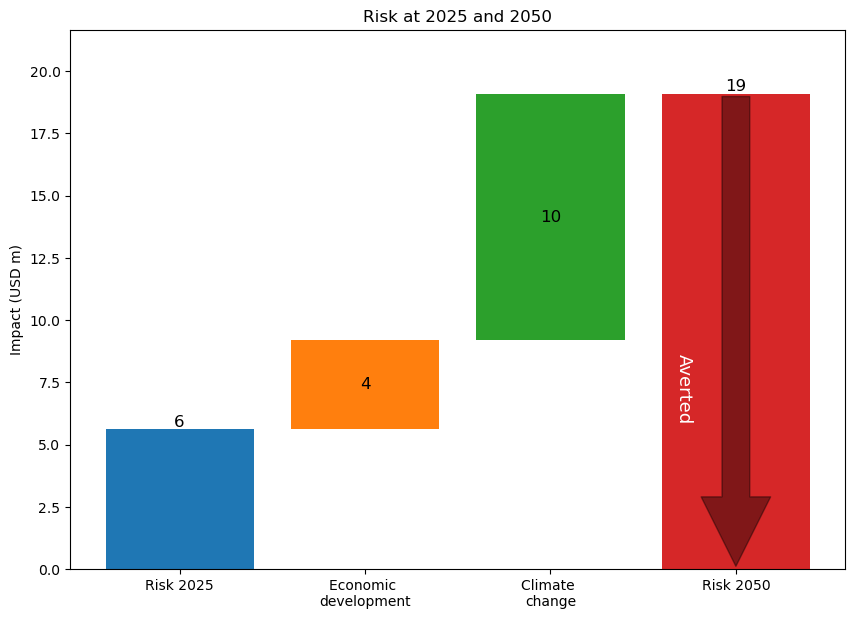

In [10]:
# Create a waterfall plot
ax = costben.plot_waterfall(
       haz_present, entity_present, haz_future, entity_future
    )

# Add an arrow showing averted risk
costben.plot_arrow_averted(
    axis=ax,
    in_meas_names=entity_present.measures.get_names()['FL'],
    accumulate=True,
    combine=False,
    risk_func=risk_aai_agg,
    disc_rates=None,
    imp_time_depen=1,
)

fig = ax.figure
fig.set_size_inches(10, 7)
ax.set_ylim(0, ax.get_ylim()[1] * 1.08)  # headroom so the bar value labels clear the arrow
for text in ax.texts:
    if text.get_text() == "Averted":
        # Move the label from the arrow tip onto the shaft, in white for contrast
        text.set_position((text.get_position()[0] - 0.28, ax.get_ylim()[1] * 0.40))
        text.set_color("white")
        text.set_fontsize(13)
fig.savefig(OUTPUT_DIR / "brazil_schools_waterfall_averted_risk.png", dpi=420, bbox_inches="tight")

### Maps for decision-makers

Two Porto Alegre maps to accompany the charts:

1. **Where the risk is** — expected annual impact per school (2025, no adaptation) over a city basemap, highlighting risk hotspots.
2. **What the relocation measure does** — the 100-year flood depth footprint with all 122 schools, marking the 5 schools proposed for partial relocation.

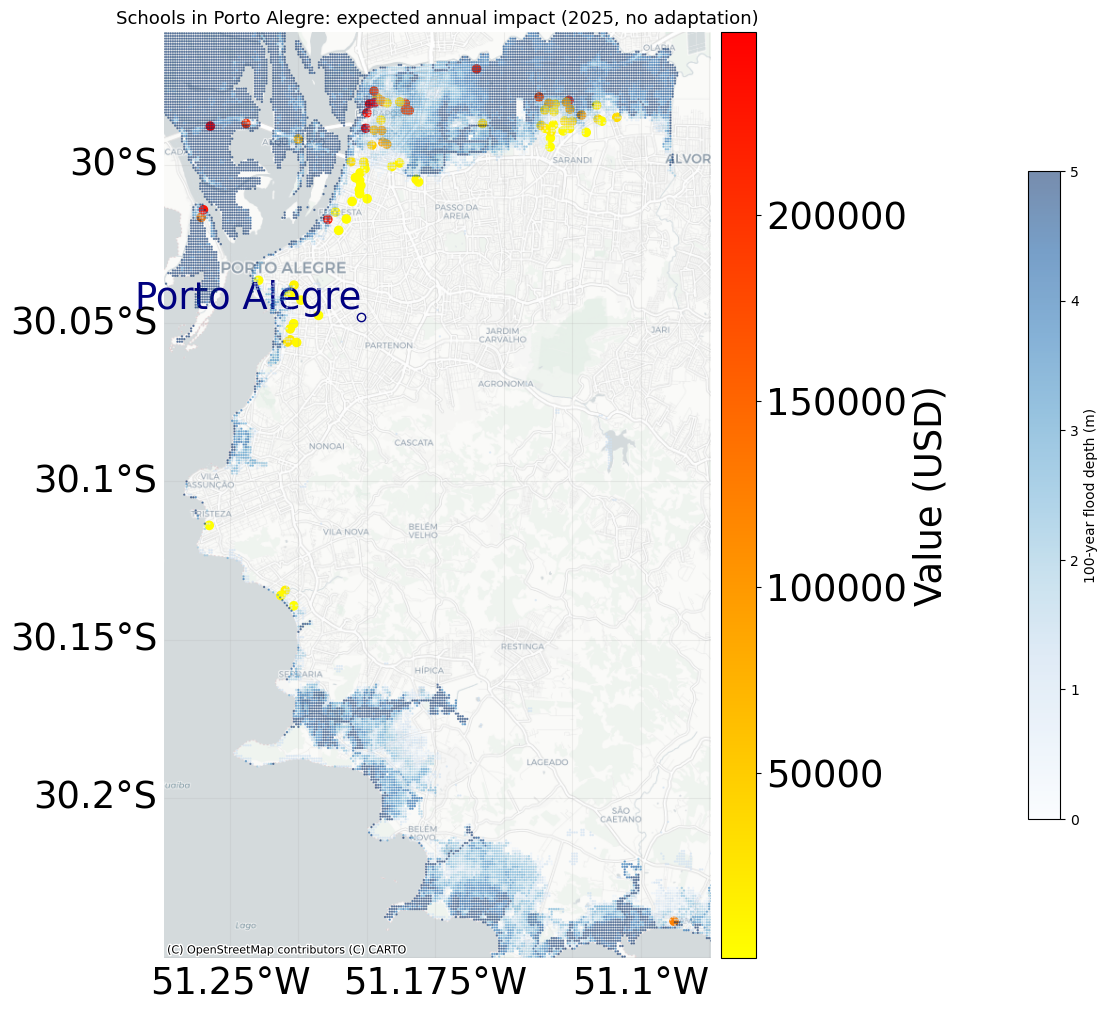

In [11]:
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from matplotlib.ticker import ScalarFormatter
from climada.engine import ImpactCalc

imp_present = ImpactCalc(
    entity_present.exposures, entity_present.impact_funcs, haz_present
).impact(save_mat=False, assign_centroids=False)

ax = imp_present.plot_basemap_eai_exposure(
    ignore_zero=True,
    buffer=1500,
    s=35,
    zoom=12,
    url=ctx.providers.CartoDB.Positron,
    cmap="autumn_r",
    figsize=(12, 10),
)
cbar_ax = ax.figure.axes[-1]
fmt = ScalarFormatter(useOffset=False)
fmt.set_scientific(False)
cbar_ax.yaxis.set_major_formatter(fmt)

ax.set_title(
    "Schools in Porto Alegre: expected annual impact (2025, no adaptation)",
    fontsize=13,
)

# Overlay the 100-year flood-depth 'mancha' on top of the EAI points (as with
# the relocation map, the hazard patch is always drawn/kept above the exposure
# layer -- zorder=5 puts it above the EAI scatter's default zorder)
rp100_idx = HAZARD_RETURN_PERIODS.index(100)
depth = haz_present.intensity[rp100_idx, :].toarray().flatten()
flooded = depth > 0.05
sc_depth = ax.scatter(
    haz_present.centroids.lon[flooded],
    haz_present.centroids.lat[flooded],
    c=depth[flooded], s=0.5, cmap="Blues",
    norm=mcolors.Normalize(0, 5), alpha=0.55, zorder=5,
    transform=ccrs.PlateCarree(),
)
plt.colorbar(sc_depth, ax=ax, shrink=0.7, pad=0.12, label="100-year flood depth (m)")

ax.figure.savefig(OUTPUT_DIR / "brazil_schools_map_expected_annual_impact.png", dpi=420, bbox_inches="tight")

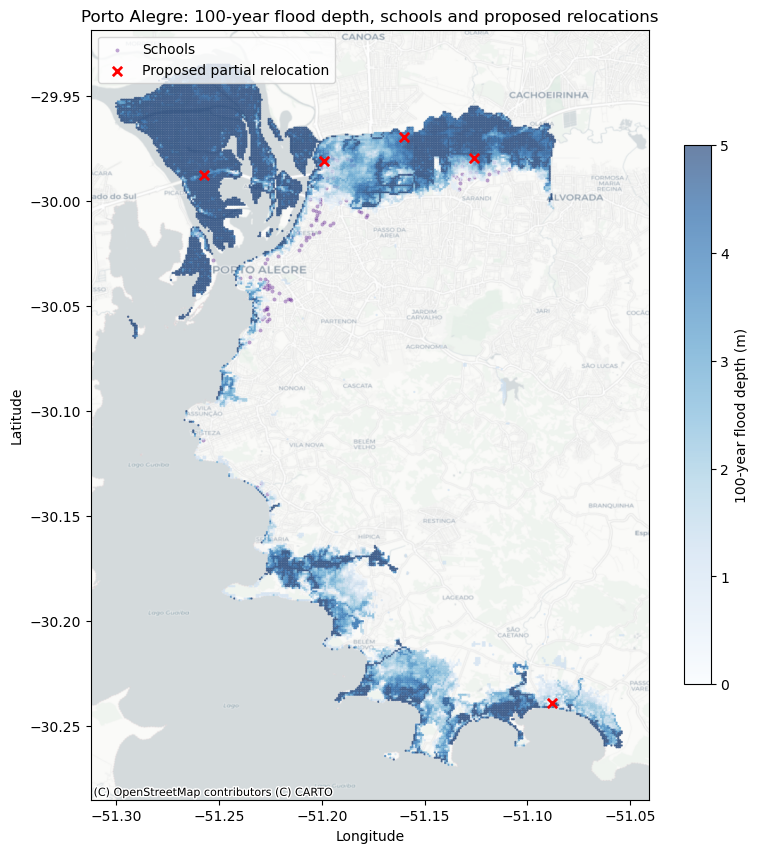

In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

rp100_idx = HAZARD_RETURN_PERIODS.index(100)
depth = haz_present.intensity[rp100_idx, :].toarray().flatten()
flooded = depth > 0.05

fig2, ax2 = plt.subplots(figsize=(9, 10))

# Draw order (and explicit zorder as a safety net): exposure points at the
# bottom, the flood-depth 'mancha' (hazard patch) above them so it always
# stays visible instead of being covered by dense exposure scatter, and the
# relocation markers on top of everything so they remain a clear call-out.
ax2.scatter(
    entity_present.exposures.longitude, entity_present.exposures.latitude,
    s=8, c="#4b0082", alpha=0.35, linewidths=0, zorder=1, label="Schools",
)

sc = ax2.scatter(
    haz_present.centroids.lon[flooded],
    haz_present.centroids.lat[flooded],
    c=depth[flooded], s=0.5, cmap="Blues",
    norm=mcolors.Normalize(0, 5), alpha=0.6, zorder=2,
)
plt.colorbar(sc, ax=ax2, shrink=0.7, label="100-year flood depth (m)")

ax2.scatter(
    entity_present.exposures.longitude[relocated_mask],
    entity_present.exposures.latitude[relocated_mask],
    s=45, c="red", marker="x", linewidths=2, zorder=3, label="Proposed partial relocation",
)
try:
    import contextily as ctx
    ctx.add_basemap(ax2, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron, zoom=12)
except Exception as err:  # tiles need internet; the map still works without them
    print(f"Basemap unavailable ({err}); continuing without it")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.legend(loc="upper left")
ax2.set_title("Porto Alegre: 100-year flood depth, schools and proposed relocations")
fig2.savefig(OUTPUT_DIR / "brazil_map_rp100_depth_schools.png", dpi=420, bbox_inches="tight")

### Extensions to this notebook

Note: this is a first version of the cost-benefit notebook. It should give you enough information to build and run your own cost-benefit analyses.

There are still a few topics to look at in more depth:
- the effects of discount rates on an analysis
- the effects of time dependency on an analysis
- mapping benefits
- working with multiple asset types
- insurance as a Measure
- other properties of the CostBenefit class

There are still a few improvements to make to the data:
- use of projected socioeconomic change information to estimate future school assets
- more scientifically-grounded estimations of the changes of flood return periods under climate change
- include upkeep costs in the Measures


In [13]:
for f in [
    "brazil_schools_cost_benefit.png",
    "brazil_schools_benefits_by_return_period.png",
    "brazil_schools_waterfall_averted_risk.png",
    "brazil_schools_map_expected_annual_impact.png",
    "brazil_map_rp100_depth_schools.png",
]:
    size = (OUTPUT_DIR / f).stat().st_size
    assert size > 10_000, f"{f} looks too small ({size} bytes)"
    print(f"{f}: {size:,} bytes")

brazil_schools_cost_benefit.png: 299,337 bytes
brazil_schools_benefits_by_return_period.png: 257,862 bytes
brazil_schools_waterfall_averted_risk.png: 153,688 bytes
brazil_schools_map_expected_annual_impact.png: 7,119,455 bytes
brazil_map_rp100_depth_schools.png: 5,188,672 bytes
